In [2]:
import os
print(os.getcwd())

C:\Users\dell\Desktop\Project (ETL)


In [3]:
import os
print(os.listdir())

['.git', '.ipynb_checkpoints', 'anaconda_projects', 'bluestock_mf.db', 'charts', 'clean_data.py', 'dashboard', 'data', 'data_dictionary.md', 'data_ingestion.py', 'day2_etl.ipynb', 'EDA_Analysis.ipynb', 'notebooks', 'Performance_Analytics.ipynb', 'queries.sql', 'README.md', 'reports', 'requirements.txt', 'schema.sql', 'sql', 'venv']


In [4]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\data\raw\hdfc_top100_nav.csv"
)

First 5 Rows:
         date       nav
0  01-06-2026  192.3195
1  31-05-2026  193.6836
2  29-05-2026  193.6848
3  27-05-2026  195.0501
4  26-05-2026  194.2258

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3091 entries, 0 to 3090
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3091 non-null   object 
 1   nav     3091 non-null   float64
dtypes: float64(1), object(1)
memory usage: 48.4+ KB
None

First 10 Rows with Daily Return:
           date      nav  daily_return
3090 2013-11-18  13.0894           NaN
3089 2013-11-19  13.1068      0.001329
3088 2013-11-20  12.9549     -0.011589
3087 2013-11-21  12.7957     -0.012289
3086 2013-11-22  12.7775     -0.001422
3085 2013-11-25  12.8548      0.006050
3084 2013-11-26  12.8591      0.000335
3083 2013-11-27  12.8389     -0.001571
3082 2013-11-28  12.8773      0.002991
3081 2013-11-29  12.9509      0.005715

Daily Return Summary:
count    3090.000000
mean       

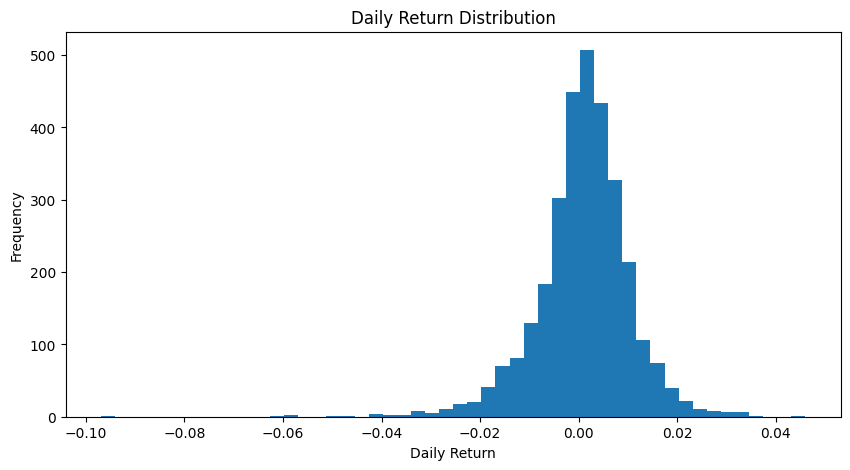

Output Saved: nav_with_daily_returns.csv


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\data\raw\hdfc_top100_nav.csv"
)


print("First 5 Rows:")
print(df.head())

print("\nData Info:")
print(df.info())

df['date'] = pd.to_datetime(
    df['date'],
    format='%d-%m-%Y'
)


df = df.sort_values('date')

df['daily_return'] = df['nav'].pct_change()


print("\nFirst 10 Rows with Daily Return:")
print(df[['date', 'nav', 'daily_return']].head(10))

print("\nDaily Return Summary:")
print(df['daily_return'].describe())


print("\nReturns Greater Than 5%:")
print(df[df['daily_return'] > 0.05])

print("\nReturns Less Than -5%:")
print(df[df['daily_return'] < -0.05])


plt.figure(figsize=(10,5))

plt.hist(
    df['daily_return'].dropna(),
    bins=50
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()


df.to_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\data\processed\nav_with_daily_returns.csv",
    index=False
)
print("Output Saved: nav_with_daily_returns.csv")

In [7]:
import pandas as pd


df = pd.read_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\data\raw\hdfc_top100_nav.csv"
)

# Convert Date
df['date'] = pd.to_datetime(
    df['date'],
    format='%d-%m-%Y'
)


df = df.sort_values('date')



start_nav = df.iloc[0]['nav']
end_nav = df.iloc[-1]['nav']

start_date = df.iloc[0]['date']
end_date = df.iloc[-1]['date']


years = (
    end_date - start_date
).days / 365

cagr = (
    (end_nav / start_nav)
    ** (1 / years)
) - 1


print("Start Date :", start_date.date())
print("End Date   :", end_date.date())

print("Start NAV  :", round(start_nav,4))
print("End NAV    :", round(end_nav,4))

print("Years      :", round(years,2))

print(
    "CAGR       :",
    round(cagr*100,2),
    "%"
)

Start Date : 2013-11-18
End Date   : 2026-06-01
Start NAV  : 13.0894
End NAV    : 192.3195
Years      : 12.54
CAGR       : 23.89 %


In [8]:
import pandas as pd
import numpy as np


df = pd.read_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\data\raw\hdfc_top100_nav.csv"
)

df['date'] = pd.to_datetime(
    df['date'],
    format='%d-%m-%Y'
)

df = df.sort_values('date')


df['daily_return'] = df['nav'].pct_change()


rf = 0.065


annual_return = (
    df['daily_return'].mean()
    * 252
)


annual_volatility = (
    df['daily_return'].std()
    * np.sqrt(252)
)


sharpe_ratio = (
    annual_return - rf
) / annual_volatility


print(
    "Annual Return :",
    round(annual_return * 100, 2),
    "%"
)

print(
    "Annual Volatility :",
    round(annual_volatility * 100, 2),
    "%"
)

print(
    "Risk Free Rate :",
    rf * 100,
    "%"
)

print(
    "Sharpe Ratio :",
    round(sharpe_ratio, 4)
)

Annual Return : 23.09 %
Annual Volatility : 15.21 %
Risk Free Rate : 6.5 %
Sharpe Ratio : 1.0905


In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\data\raw\hdfc_top100_nav.csv"
)

df['date'] = pd.to_datetime(
    df['date'],
    format='%d-%m-%Y'
)

df = df.sort_values('date')

df['daily_return'] = df['nav'].pct_change()

rf = 0.065

annual_return = df['daily_return'].mean() * 252

downside_returns = df[df['daily_return'] < 0]['daily_return']

downside_volatility = downside_returns.std() * np.sqrt(252)

sortino_ratio = (
    annual_return - rf
) / downside_volatility

print("Annual Return:", round(annual_return * 100, 2), "%")
print("Downside Volatility:", round(downside_volatility * 100, 2), "%")
print("Risk Free Rate:", rf * 100, "%")
print("Sortino Ratio:", round(sortino_ratio, 4))

Annual Return: 23.09 %
Downside Volatility: 12.57 %
Risk Free Rate: 6.5 %
Sortino Ratio: 1.32


In [27]:
import pandas as pd
from scipy.stats import linregress

fund = pd.read_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\data\raw\hdfc_top100_nav.csv"
)

benchmark = pd.read_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\data\raw\10_benchmark_indices.csv"
)

fund['date'] = pd.to_datetime(fund['date'], format='%d-%m-%Y')
benchmark['date'] = pd.to_datetime(benchmark['date'])


fund = fund.sort_values('date')
benchmark = benchmark.sort_values('date')


fund['fund_return'] = fund['nav'].pct_change()

benchmark = benchmark[benchmark['index_name'] == 'NIFTY100'].copy()
benchmark['benchmark_return'] = benchmark['close_value'].pct_change()

merged = pd.merge(
    fund[['date', 'fund_return']],
    benchmark[['date', 'benchmark_return']],
    on='date',
    how='inner'
)

merged = merged.dropna()

# Regression
beta, intercept, r_value, p_value, std_err = linregress(
    merged['benchmark_return'],
    merged['fund_return']
)

alpha = intercept * 252

r_squared = r_value ** 2

# Print results
print("Alpha :", round(alpha, 4))
print("Beta  :", round(beta, 4))
print("R-Squared :", round(r_squared, 4))

result = pd.DataFrame({
    "alpha": [alpha],
    "beta": [beta],
    "r_squared": [r_squared]
})

result.to_csv("alpha_beta.csv", index=False)

print("alpha_beta.csv created successfully ✔️")

Alpha : 0.1255
Beta  : -0.0011
R-Squared : 0.0
alpha_beta.csv created successfully ✔️


In [14]:
print("Merged Rows:", len(merged))

print("\nDate Range:")
print(merged['date'].min())
print(merged['date'].max())

print("\nFund Return Summary:")
print(merged['fund_return'].describe())

print("\nBenchmark Return Summary:")
print(merged['benchmark_return'].describe())

Merged Rows: 1081

Date Range:
2022-01-04 00:00:00
2026-05-29 00:00:00

Fund Return Summary:
count    1081.000000
mean        0.000498
std         0.008733
min        -0.045777
25%        -0.003111
50%         0.001183
75%         0.005149
max         0.034111
Name: fund_return, dtype: float64

Benchmark Return Summary:
count    1081.000000
mean        0.000114
std         0.008173
min        -0.026873
25%        -0.005385
50%        -0.000103
75%         0.005456
max         0.024839
Name: benchmark_return, dtype: float64


In [15]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\data\raw\hdfc_top100_nav.csv"
)

df['date'] = pd.to_datetime(
    df['date'],
    format='%d-%m-%Y'
)

df = df.sort_values('date')

df['running_max'] = df['nav'].cummax()

df['drawdown'] = (
    df['nav'] / df['running_max']
) - 1

max_drawdown = df['drawdown'].min()

worst_row = df.loc[df['drawdown'].idxmin()]

print("Maximum Drawdown:", round(max_drawdown * 100, 2), "%")
print("Worst Date:", worst_row['date'].date())
print("NAV on Worst Date:", round(worst_row['nav'], 4))

Maximum Drawdown: -40.26 %
Worst Date: 2020-03-24
NAV on Worst Date: 41.26


In [18]:
import pandas as pd

nav = pd.read_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\data\raw\02_nav_history.csv"
)

print("Unique Funds:", nav['amfi_code'].nunique())

Unique Funds: 40


In [19]:
fund_master = pd.read_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\data\raw\01_fund_master.csv"
)

print(fund_master[['amfi_code','scheme_name','expense_ratio_pct']].head())

   amfi_code                                   scheme_name  expense_ratio_pct
0     119551     SBI Bluechip Fund - Regular Plan - Growth               1.54
1     119552      SBI Bluechip Fund - Direct Plan - Growth               0.66
2     119598    SBI Small Cap Fund - Regular Plan - Growth               1.43
3     119599     SBI Small Cap Fund - Direct Plan - Growth               0.72
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth               0.77


In [20]:
import pandas as pd
import numpy as np

nav = pd.read_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\data\raw\02_nav_history.csv"
)

fund_master = pd.read_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\data\raw\01_fund_master.csv"
)

nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

rf = 0.065

results = []

for fund, group in nav.groupby('amfi_code'):

    group = group.sort_values('date')

    if len(group) < 252:
        continue

    annual_return = (
        group['daily_return'].mean() * 252
    )

    annual_volatility = (
        group['daily_return'].std() * np.sqrt(252)
    )

    sharpe = (
        (annual_return - rf)
        / annual_volatility
    )

    group['running_max'] = (
        group['nav'].cummax()
    )

    group['drawdown'] = (
        group['nav']
        / group['running_max']
    ) - 1

    max_dd = group['drawdown'].min()

    end_nav = group.iloc[-1]['nav']

    three_year_data = group.tail(756)

    start_nav = three_year_data.iloc[0]['nav']

    three_year_return = (
        (end_nav / start_nav) ** (1/3)
    ) - 1

    results.append([
        fund,
        three_year_return,
        sharpe,
        max_dd
    ])

metrics = pd.DataFrame(
    results,
    columns=[
        'amfi_code',
        'three_year_return',
        'sharpe_ratio',
        'max_drawdown'
    ]
)

scorecard = metrics.merge(
    fund_master[
        [
            'amfi_code',
            'scheme_name',
            'expense_ratio_pct'
        ]
    ],
    on='amfi_code',
    how='left'
)

scorecard['return_rank'] = (
    scorecard['three_year_return']
    .rank(ascending=False)
)

scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(ascending=False)
)

scorecard['expense_rank'] = (
    scorecard['expense_ratio_pct']
    .rank(ascending=True)
)

scorecard['drawdown_rank'] = (
    scorecard['max_drawdown']
    .rank(ascending=False)
)

scorecard['fund_score'] = (
    0.30 * scorecard['return_rank'] +
    0.25 * scorecard['sharpe_rank'] +
    0.15 * scorecard['expense_rank'] +
    0.10 * scorecard['drawdown_rank']
)

scorecard['fund_score'] = (
    100 *
    (
        scorecard['fund_score'].max()
        - scorecard['fund_score']
    )
    /
    (
        scorecard['fund_score'].max()
        - scorecard['fund_score'].min()
    )
)

scorecard = scorecard.sort_values(
    'fund_score',
    ascending=False
)

print(
    scorecard[
        [
            'scheme_name',
            'fund_score'
        ]
    ].head(10)
)

scorecard.to_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully")

                                          scheme_name  fund_score
34      Mirae Asset Large Cap Fund - Regular - Growth  100.000000
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...   94.557823
24          ICICI Pru Bluechip Fund - Direct - Growth   92.743764
25           ICICI Pru Midcap Fund - Regular - Growth   91.836735
30             Kotak Flexicap Fund - Regular - Growth   89.115646
16                Axis Midcap Fund - Regular - Growth   87.755102
3       ABSL Frontline Equity Fund - Regular - Growth   82.653061
19          SBI Bluechip Fund - Regular Plan - Growth   81.972789
20           SBI Bluechip Fund - Direct Plan - Growth   73.242630
36      Mirae Asset Tax Saver Fund - Regular - Growth   70.408163
fund_scorecard.csv saved successfully


Notebook Conclusion

A composite fund scorecard was created using 3-year return, Sharpe Ratio, expense ratio, and maximum drawdown rankings. Funds were ranked and normalized to a 0–100 scale, where higher scores indicate stronger overall performance. Mirae Asset Large Cap Fund achieved the highest score among the evaluated funds.

In [21]:
import pandas as pd

benchmark = pd.read_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\data\raw\10_benchmark_indices.csv"
)

print(benchmark['index_name'].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [22]:
scorecard = pd.read_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\fund_scorecard.csv"
)

print(scorecard[['amfi_code','scheme_name','fund_score']].head())

   amfi_code                                        scheme_name  fund_score
0     148567      Mirae Asset Large Cap Fund - Regular - Growth  100.000000
1     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   94.557823
2     120504          ICICI Pru Bluechip Fund - Direct - Growth   92.743764
3     120505           ICICI Pru Midcap Fund - Regular - Growth   91.836735
4     120843             Kotak Flexicap Fund - Regular - Growth   89.115646


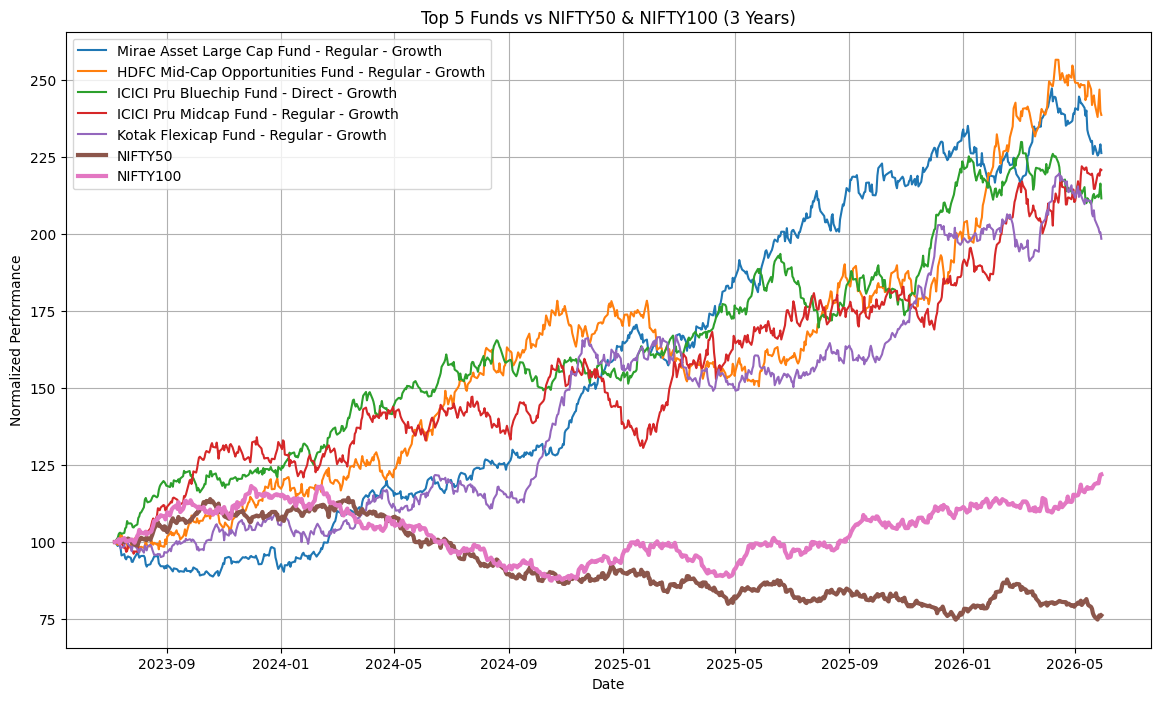

   amfi_code                                        scheme_name  \
0     148567      Mirae Asset Large Cap Fund - Regular - Growth   
1     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
2     120504          ICICI Pru Bluechip Fund - Direct - Growth   
3     120505           ICICI Pru Midcap Fund - Regular - Growth   
4     120843             Kotak Flexicap Fund - Regular - Growth   

   tracking_error  
0        0.188733  
1        0.225593  
2        0.186712  
3        0.231336  
4        0.206117  
benchmark_comparison_chart.png saved successfully
tracking_error.csv saved successfully


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\data\raw\02_nav_history.csv"
)

benchmark = pd.read_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\data\raw\10_benchmark_indices.csv"
)

scorecard = pd.read_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\fund_scorecard.csv"
)

nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

top5_codes = [
    148567,
    100033,
    120504,
    120505,
    120843
]

top5_names = scorecard.set_index(
    'amfi_code'
)['scheme_name'].to_dict()

plt.figure(figsize=(14,8))

tracking_error_results = []

for code in top5_codes:

    fund = nav[
        nav['amfi_code'] == code
    ].copy()

    fund = fund.sort_values('date')

    fund = fund.tail(756)

    fund['normalized'] = (
        fund['nav']
        / fund['nav'].iloc[0]
    ) * 100

    plt.plot(
        fund['date'],
        fund['normalized'],
        label=top5_names[code]
    )

    fund['fund_return'] = (
        fund['nav'].pct_change()
    )

    nifty100 = benchmark[
        benchmark['index_name'] == 'NIFTY100'
    ].copy()

    nifty100 = nifty100.sort_values('date')

    nifty100['benchmark_return'] = (
        nifty100['close_value'].pct_change()
    )

    merged = pd.merge(
        fund[['date','fund_return']],
        nifty100[['date','benchmark_return']],
        on='date',
        how='inner'
    ).dropna()

    tracking_error = (
        np.std(
            merged['fund_return']
            - merged['benchmark_return']
        )
        * np.sqrt(252)
    )

    tracking_error_results.append(
        [
            code,
            top5_names[code],
            tracking_error
        ]
    )

nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty50 = nifty50.sort_values('date').tail(756)

nifty50['normalized'] = (
    nifty50['close_value']
    / nifty50['close_value'].iloc[0]
) * 100

plt.plot(
    nifty50['date'],
    nifty50['normalized'],
    linewidth=3,
    label='NIFTY50'
)

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100 = nifty100.sort_values('date').tail(756)

nifty100['normalized'] = (
    nifty100['close_value']
    / nifty100['close_value'].iloc[0]
) * 100

plt.plot(
    nifty100['date'],
    nifty100['normalized'],
    linewidth=3,
    label='NIFTY100'
)

plt.title(
    'Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)'
)

plt.xlabel('Date')
plt.ylabel('Normalized Performance')

plt.legend()

plt.grid(True)

plt.savefig(
    r"C:\Users\dell\Desktop\Project (ETL)\benchmark_comparison_chart.png",
    bbox_inches='tight'
)

plt.show()

tracking_error_df = pd.DataFrame(
    tracking_error_results,
    columns=[
        'amfi_code',
        'scheme_name',
        'tracking_error'
    ]
)

print(tracking_error_df)

tracking_error_df.to_csv(
    r"C:\Users\dell\Desktop\Project (ETL)\tracking_error.csv",
    index=False
)

print("benchmark_comparison_chart.png saved successfully")
print("tracking_error.csv saved successfully")